# Regridding NetCDF files to a reference grid for model comparison

This script regrids `.nc` files with spatial `x`, `y`, `lon(x, y)`, and `lat(x, y)` coordinates onto a reference grid. This is necessary to compare data from different models on a common grid.

### Libraries:

The following libraries and functions are required to run this script.

In [1]:
#Import libraries:

import xarray as xr #Read and work with netCDF files
import numpy as np #Work with arrays and perform numerical operations
import matplotlib.pyplot as plt #Create plots and visualizations
import cartopy.crs as ccrs #Work with cartographic projections and create maps
# from scipy.interpolate import griddata # Interpolate data points onto a new grid  ->Uncomment in server
import requests #Make HTTP requests to access data from the I4C API
import sys
sys.path.append("..")# Allow the script to import files located one directory level above the current file
# from utils.interpolation import Interpolator # Import the Interpolator class used for regridding
from utils.DestinyGridParameters import newlonlat_city  # Import the function that defines the target grid for each city

#interpolation.py was downloaded from 'https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/interpolation.py'
import os # Work with folders and file paths
from pathlib import Path
import glob
import xesmf as xe

### Definition of global variables:

In this cell, the file name, the data version, the data path, the output path and the city name are defined. Information such as the variable name, domain, reanalysis, simulation type, model, time interval, and time period is also extracted from the file name. These values will be used later in the script.

In [ ]:
#City name and data info:
variable = 'tas'
reanalisis = 'ERA5'
simulation_type = 'evaluation'
run_type1 = 'r1i1p1f1'
runing_centre = 'BCCR-UCAN'
model = 'WRF451R-CI4C'
run_type2 = 'v1-r1'
time_interval = '1hr'
data_version = 'v20240710'
city_name='Paris'

# Obtaination of the domain from the city_name
if city_name == 'Paris' or city_name == 'Barcelona' or city_name == 'Prage':
    # domain = 'ALPX-3i' 
    domain = 'ALPX-3f'#For my data, the current version is called ALPX-3i.
elif city_name == 'Bergen' or city_name == 'Hamburg' or city_name == 'NewCastle':
    domain = 'NSEA-3i-'

#Interpolation method:
interpolation_method = 'bilinear'

In [3]:
# Find files with the characteristics specified above
data_directory = '../I4C_CPRCM_DATA/'
path_list = sorted(glob.glob(f"{data_directory}{domain}/{runing_centre}/{reanalisis}/{simulation_type}/{run_type1}/{model}/{run_type2}/{time_interval}/{variable}/{data_version}/*.nc"))

### Crop and interpolate the files in `file_list`, and save them in a single file

First, the target I4C grid and its parameters are obtained for the selected city using the newlonlat_city() function defined in the utils folder. These parameters are based on the city grids defined in the I4C GitHub repository and include the target longitude and latitude coordinates, domain limits, grid size, and grid spacing.

Each NetCDF file in file_list is then opened and cropped to an area extending one degree beyond the target city domain. This additional margin prevents the loss of boundary points during interpolation.

The cropped dataset is interpolated onto the target I4C grid using bilinear interpolation. Other methods can be selected by changing interpolation_method, such as nearest_s2d, patch, conservative, or conservative_normed.

After interpolation, the additional one-degree margin is removed to retain only the target city domain. The resulting dataset from each file is added to results.

Finally, all interpolated datasets are concatenated along the time dimension into a single dataset.

In [ ]:
## target grid:

#Calculate the I4C grid for the city according the GitHub repository and save the grid parameters:
new_longitude, new_latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend = newlonlat_city(city_name)
#New_longitude and new_latitude already have the limits expanded

# Define the target grid as a dataset: Necessary for xESMF regridding
ds_out = xr.Dataset(coords={ "lon": ("lon", new_longitude), "lat": ("lat", new_latitude)})

##Source grid and interpolation weights: They are the same in all cases because all datasets share the same source and target grids.

#Read the file:
ds = xr.open_dataset(path_list[0])

#Crop the dataset to the city area using the grid parameters obtained from the GitHub repository:
#It was ampliated the range 1º in each side to not lose data points in the interpolation below
city = ds.where((ds.lon >= (x_first-1)) & (ds.lon <= (xend+1)) &(ds.lat >= (y_first-1)) & (ds.lat <= (yend+1)),drop=True)

# Create the source grid dataset using the original coordinates
ds_in = xr.Dataset({"lon": city["lon"], "lat": city["lat"],})

#Define the regridder: It calculates the interpolation weights. 
regridder = xe.Regridder( ds_in, ds_out, method=interpolation_method, periodic=False, ignore_degenerate=True)

## Regrid all files: 
results=[]
for file in path_list:
    #Read the file:
    ds = xr.open_dataset(file)

    #Crop the dataset to the city area using the grid parameters obtained from the GitHub repository:
    #It was ampliated the range 1º in each side to not lose data points in the interpolation below
    city = ds.where((ds.lon >= (x_first-1)) & (ds.lon <= (xend+1)) &(ds.lat >= (y_first-1)) & (ds.lat <= (yend+1)),drop=True)

    #Aply the regridder
    ds_city_interp = regridder(city[variable])

    # Crop to the extra degree:
    city_interp = ds_city_interp.where((ds_city_interp.lon >= x_first) & (ds_city_interp.lon <= xend) &(ds_city_interp.lat >= y_first) & (ds_city_interp.lat <= yend),drop=True)

    #CAlendar unification to reorder the data by time:
    city_interp = city_interp.convert_calendar("proleptic_gregorian", use_cftime=False)
    
    #save the interpolated file in the result's list
    results.append(city_interp)
## Concatenate all files along the time dimension and sort them chronologically
city_interp_all = xr.concat(results, dim="time").sortby("time")

{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(152,) (122,)


### Visualization for an example time:

The next three representations show the original data, the data after the first crop with a one-degree buffer around the boundaries, and the final result after interpolation. In the first and second figures, the grid is not regular, while in the final interpolated result it is regular.

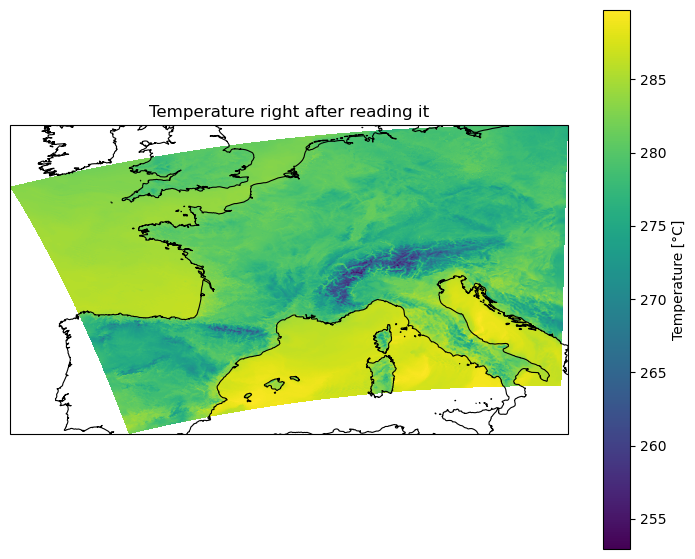

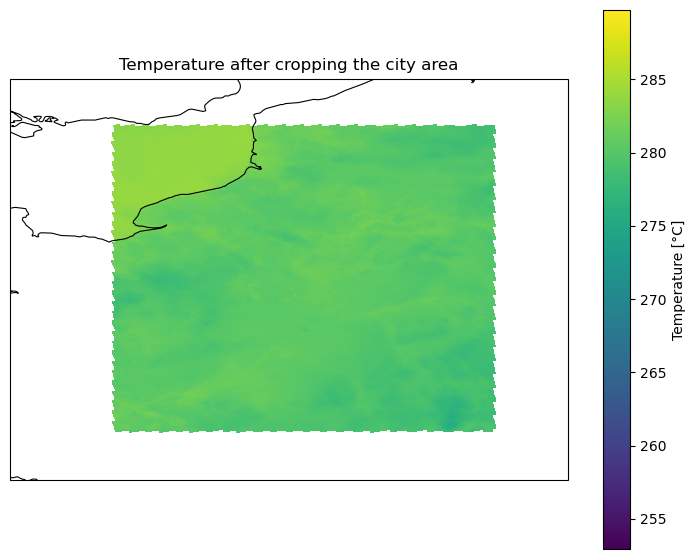

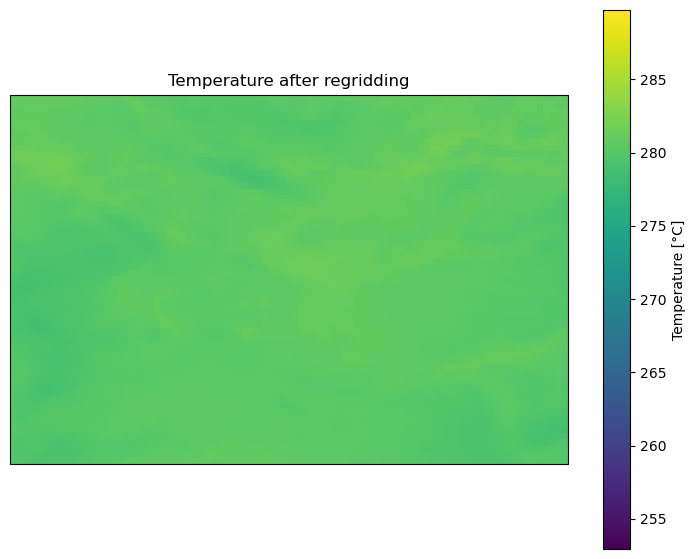

In [5]:
##Data right after reading it:

#Read the variables
T = ds[variable].isel(time=-1)
T2 = city[variable].isel(time=-1)
T3= city_interp_all.isel(time=-1)

#Obtain a unified colormap limit:
vmin = min(T.min(skipna=True).item(), T2.min(skipna=True).item(), T3.min(skipna=True).item())
vmax = max(T.max(skipna=True).item(), T2.max(skipna=True).item(), T3.max(skipna=True).item())

def representation(var, title):# Function to do representations below
    # Visualize the data with the silhouette of the continents using cartopy
    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    m = ax.pcolormesh(var["lon"],var["lat"],var,vmin=vmin, vmax=vmax, shading="auto",transform=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.8)
    plt.colorbar(m, ax=ax, label="Temperature [°C]")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    plt.show()
representation(T, "Temperature right after reading it")
representation(T2, "Temperature after cropping the city area")
representation(T3, "Temperature after regridding")

It can be seen that the boundaries become regular after interpolation, while the spatial structure of the variable remains unchanged.

### You can save the result using the code below:

In [6]:
# #Define the path where you want to save the file:
# path_save = 'data'#It save the data file in a forder called data in your current directory
# os.makedirs(path_save, exist_ok = True)#It creates folders indicated in path_save if they doesn't exist

# #Save the cropped and interpolated dataset (city_interp) as a new netCDF file in the above directory:
# base_name = Path(path_list[0]).stem.rsplit("_", 1)[0] #It takes the file name without the time period
# city_interp_all.to_netcdf(path_save+"/"+base_name+'_'+city_name+"_cropped_interpolated"+'.nc')